In [7]:
# ============================================================
# 1. INITIALISATION
# ============================================================

from pathlib import Path
import json
import pickle
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.ticker import PercentFormatter


from xgboost import XGBClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

# Reproductibilité.
RANDOM_STATE = 42

# Project paths.
PROJECT_DIR = Path.cwd().parent
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLES_DIR = OUTPUT_DIR / "tables"
OUTPUT_MODELS_DIR = OUTPUT_DIR / "models"

for directory in [
    OUTPUT_FIGURES_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Target.
TARGET = "default_flag"

# Paramètres visuels.
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

print(f"Project: {PROJECT_DIR}")
print(f"Données : {DATA_PROCESSED_DIR}")
print(f"Tables: {OUTPUT_TABLES_DIR}")
print(f"Modèles : {OUTPUT_MODELS_DIR}")

print(f"Figures: {OUTPUT_FIGURES_DIR}")


Projet : /Users/kwamekristianlaban/Documents/Projet_perso/P2
Données : /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed
Tables : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables
Modèles : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/models
Figures : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures


In [2]:
# ============================================================
# 2. LOADING UPSTREAM EXPORTS
# ============================================================

REQUIRED_FILES = {
    "benchmark_scorecard": "benchmark_scorecard_v1_avant_xgboost.csv",
    "final_comparison": "final_comparison_scorecard_xgboost.csv",
    "gains": "synthese_xgb_gainsoost_vs_scorecard.csv",
    "xgb_calibration": "xgboost_m06_comparaison_calibration.csv",
    "xgb_bands": "xgboost_m06_bandes_risque_test.csv",
    "xgb_importance": "xgboost_m06_importance_permutation_test.csv",
    "xgb_psi": "xgboost_m06_psi_scores.csv",
    "xgb_manifest": "xgboost_m06_manifest.csv",
}

missing_files = [nom for nom, fichier in REQUIRED_FILES.items() if not (OUTPUT_TABLES_DIR / fichier).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing exports: {missing_files}")

benchmark_scorecard = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["benchmark_scorecard"])
final_comparison = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["final_comparison"])
xgb_gains = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["gains"])
xgb_calibration = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["xgb_calibration"])
xgb_bands = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["xgb_bands"])
xgb_importance = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["xgb_importance"])
xgb_psi = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["xgb_psi"])
xgb_manifest = pd.read_csv(OUTPUT_TABLES_DIR / REQUIRED_FILES["xgb_manifest"])

print("Tous les exports requis ont été chargés.")
display(final_comparison)


Tous les exports requis ont été chargés.


,modèle,AUC_test,Gini_test,KS_test,AUC_PR_test,Brier_test,PSI_score_train_test,version_probabilites
0,Scorecard logistique WoE V1,0.6300,0.2600,0.1885,0.2126,0.1238,0.0131,Initiale
1,XGBoost M06 — PD recalibrées,0.6421,0.2843,0.2024,0.2236,0.1229,0.0146,Platt scaling sur validation 2014


In [3]:
# ============================================================
# 3. TABLE DE DÉCISION FINALE
# ============================================================

columns = ["modèle", "AUC_test", "Gini_test", "KS_test", "AUC_PR_test", "Brier_test", "PSI_score_train_test", "probability_version"]
decision_table = final_comparison[columns].copy()
decision_table["décision"] = np.where(
    decision_table["modèle"].str.contains("XGBoost", case=False, na=False),
    "Retenu pour performance prédictive",
    "Référence interprétable / challenger",
)

display(decision_table.style.format({
    "AUC_test": "{:.4f}", "Gini_test": "{:.4f}", "KS_test": "{:.4f}",
    "AUC_PR_test": "{:.4f}", "Brier_test": "{:.4f}", "PSI_score_train_test": "{:.4f}",
}))

DECISION_TABLE_FILE = OUTPUT_TABLES_DIR / "05_decision_table_finale.csv"
decision_table.to_csv(DECISION_TABLE_FILE, index=False)
print(f"Table exportée : {DECISION_TABLE_FILE}")


,modèle,AUC_test,Gini_test,KS_test,AUC_PR_test,Brier_test,PSI_score_train_test,version_probabilites,décision
0,Scorecard logistique WoE V1,0.6300,0.2600,0.1885,0.2126,0.1238,0.0131,Initiale,Référence interprétable / challenger
1,XGBoost M06 — PD recalibrées,0.6421,0.2843,0.2024,0.2236,0.1229,0.0146,Platt scaling sur validation 2014,Retenu pour performance prédictive


Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/05_table_decision_finale.csv


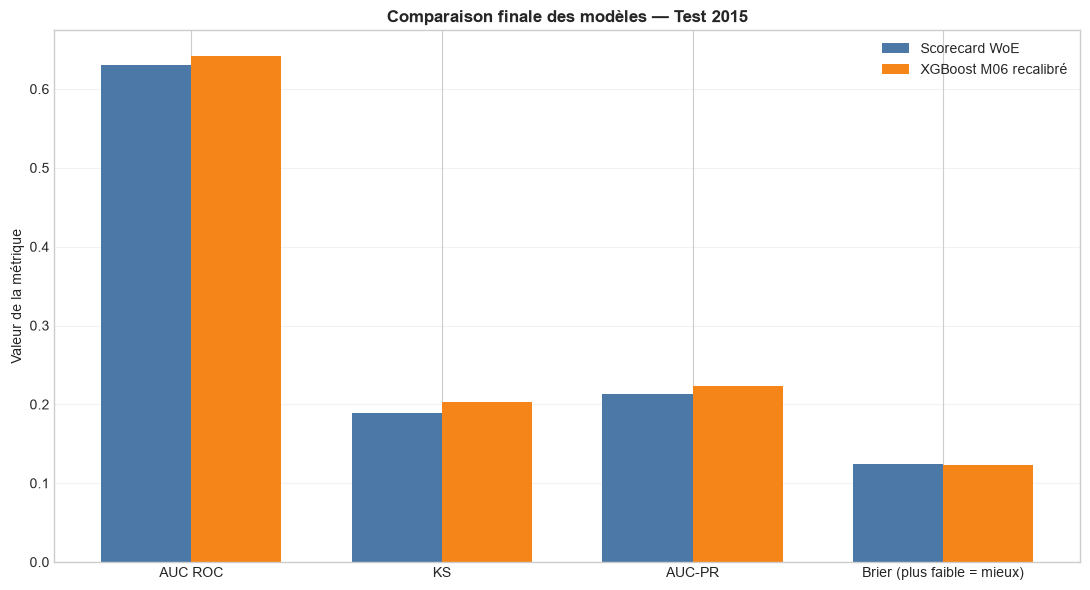

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/05_comparaison_finale_modeles.png


In [4]:
# ============================================================
# 4. FINAL COMPARISON FIGURE
# ============================================================

metrics = ["AUC_test", "KS_test", "AUC_PR_test", "Brier_test"]
labels = ["AUC ROC", "KS", "AUC-PR", "Brier (lower is better)"]
x = np.arange(len(metrics))
width = 0.36
scorecard = final_comparison.loc[final_comparison["modèle"].str.contains("Scorecard", case=False, na=False)].iloc[0]
xgb = final_comparison.loc[final_comparison["modèle"].str.contains("XGBoost", case=False, na=False)].iloc[0]

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width / 2, [scorecard[m] for m in metrics], width, label="Scorecard WoE", color="#4C78A8")
ax.bar(x + width / 2, [xgb[m] for m in metrics], width, label="XGBoost M06 recalibré", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Valeur de la métrique")
ax.set_title("Comparaison finale des modèles — Test 2015", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

FIG_COMPARAISON = OUTPUT_FIGURES_DIR / "05_final_comparison_modeles.png"
plt.savefig(FIG_COMPARAISON, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure exportée : {FIG_COMPARAISON}")


In [5]:
# ============================================================
# 5. CONTRÔLE DE LA RECALIBRATION
# ============================================================

cols_calibration = ["version", "split", "AUC_ROC", "Gini", "AUC_PR", "KS", "Brier"]
display(xgb_calibration[cols_calibration].style.format({
    "AUC_ROC": "{:.4f}", "Gini": "{:.4f}", "AUC_PR": "{:.4f}",
    "KS": "{:.4f}", "Brier": "{:.4f}",
}))

brier_test_brut = xgb_calibration.loc[(xgb_calibration["version"] == "XGBoost brut") & (xgb_calibration["split"] == "Test"), "Brier"].iloc[0]
brier_test_calibre = xgb_calibration.loc[(xgb_calibration["version"] == "XGBoost calibré") & (xgb_calibration["split"].str.contains("Test")), "Brier"].iloc[0]
print(f"Amélioration Brier test : {brier_test_brut - brier_test_calibre:.4f}")


,version,split,AUC_ROC,Gini,AUC_PR,KS,Brier
0,XGBoost brut,Validation,0.6441,0.2883,0.2103,0.2070,0.2431
1,XGBoost calibré,Validation calibrée,0.6441,0.2883,0.2103,0.2070,0.1148
2,XGBoost brut,Test,0.6421,0.2843,0.2236,0.2024,0.2420
3,XGBoost calibré,Test calibré,0.6421,0.2843,0.2236,0.2024,0.1229


Amélioration Brier test : 0.1191


,bande_risque,n_prets,part_portefeuille,pd_moyenne_predite,taux_defaut_observe,lift_vs_portefeuille,ecart_pd_moins_observe
0,1 - Très faible risque,57149,20.19%,5.94%,6.30%,0.42x,-0.36%
1,2 - Faible risque,57026,20.15%,9.72%,11.28%,0.76x,-1.56%
2,3 - Intermédiaire,56826,20.08%,13.14%,14.65%,0.98x,-1.51%
3,4 - Risqué,55749,19.70%,17.04%,18.35%,1.23x,-1.31%
4,5 - Très risqué,56271,19.88%,22.82%,24.07%,1.62x,-1.25%


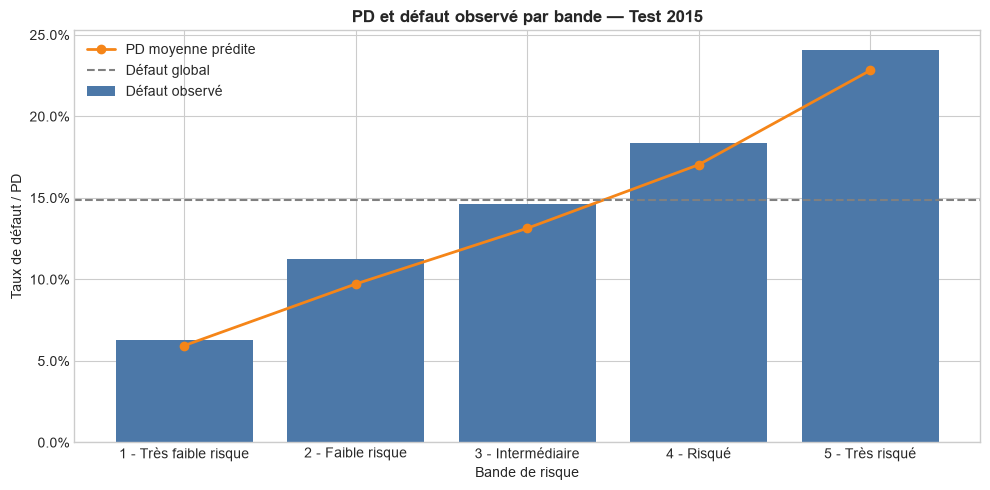

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/05_bandes_risque_xgboost.png


In [8]:
# ============================================================
# 6. ANALYSE DES BANDES DE RISQUE
# ============================================================

bandes = xgb_bands.copy()
bandes["ecart_pd_moins_observe"] = bandes["pd_moyenne_predite"] - bandes["taux_defaut_observe"]
bandes["ordre"] = bandes["bande_risque"].str.extract(r"(\d+)").astype(int)
bandes = bandes.sort_values("ordre")

display(bandes[[
    "bande_risque", "n_prets", "part_portefeuille", "pd_moyenne_predite",
    "taux_defaut_observe", "lift_vs_portefeuille", "ecart_pd_moins_observe",
]].style.format({
    "part_portefeuille": "{:.2%}", "pd_moyenne_predite": "{:.2%}",
    "taux_defaut_observe": "{:.2%}", "lift_vs_portefeuille": "{:.2f}x",
    "ecart_pd_moins_observe": "{:+.2%}",
}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bandes["bande_risque"], bandes["taux_defaut_observe"], color="#4C78A8", label="Défaut observé")
ax.plot(bandes["bande_risque"], bandes["pd_moyenne_predite"], color="#F58518", marker="o", linewidth=2, label="PD moyenne prédite")
ax.axhline(bandes["taux_defaut_observe"].mul(bandes["n_prets"]).sum() / bandes["n_prets"].sum(), color="gray", linestyle="--", label="Défaut global")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title("PD et défaut observé par bande — Test 2015", fontweight="bold")
ax.set_xlabel("Bande de risque")
ax.set_ylabel("Taux de défaut / PD")
ax.legend()
plt.tight_layout()
FIG_BANDES = OUTPUT_FIGURES_DIR / "05_bandes_risque_xgboost.png"
plt.savefig(FIG_BANDES, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure exportée : {FIG_BANDES}")


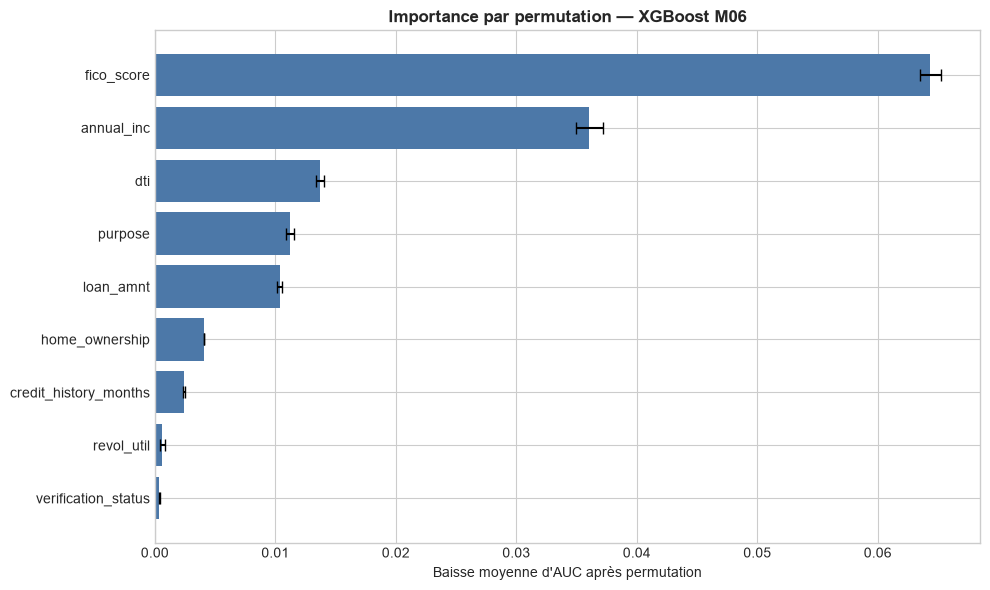

,variable,AUC_reference,baisse_AUC_moyenne,baisse_AUC_ecart_type,baisse_AUC_min,baisse_AUC_max
0,fico_score,0.6421,0.0644,0.0008,0.063006,0.065201
1,annual_inc,0.6421,0.0361,0.0011,0.034246,0.037147
2,dti,0.6421,0.0137,0.0003,0.013353,0.014234
3,purpose,0.6421,0.0112,0.0003,0.010863,0.011767
4,loan_amnt,0.6421,0.0104,0.0002,0.010000,0.010608
5,home_ownership,0.6421,0.0041,0.0000,0.004048,0.004103
6,credit_history_months,0.6421,0.0024,0.0001,0.002341,0.002547
7,revol_util,0.6421,0.0006,0.0002,0.000294,0.000919
8,verification_status,0.6421,0.0004,0.0000,0.000346,0.000415


,comparaison,PSI_score,interprétation
0,Train vs Validation,0.0163,Stable
1,Train vs Test,0.0146,Stable


In [9]:
# ============================================================
# 7. IMPORTANCE ET PSI
# ============================================================

importance = xgb_importance.sort_values("baisse_AUC_moyenne", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance["variable"], importance["baisse_AUC_moyenne"], xerr=importance["baisse_AUC_ecart_type"], color="#4C78A8", capsize=4)
ax.set_title("Importance par permutation — XGBoost M06", fontweight="bold")
ax.set_xlabel("Baisse moyenne d'AUC après permutation")
plt.tight_layout()
FIG_IMPORTANCE = OUTPUT_FIGURES_DIR / "05_xgb_importanceoost.png"
plt.savefig(FIG_IMPORTANCE, dpi=150, bbox_inches="tight")
plt.show()
display(xgb_importance.style.format({"AUC_reference":"{:.4f}", "baisse_AUC_moyenne":"{:.4f}", "baisse_AUC_ecart_type":"{:.4f}"}))

display(xgb_psi.style.format({"PSI_score": "{:.4f}"}))


In [10]:
# ============================================================
# 8. PLAN DE MONITORING
# ============================================================

plan_monitoring = pd.DataFrame({
    "indicateur": ["PSI des PD", "Brier score", "AUC / Gini", "KS", "Défaut observé par bande", "Écart PD - défaut observé"],
    "fréquence": ["Mensuelle", "Mensuelle / trimestrielle", "Trimestrielle", "Trimestrielle", "Mensuelle", "Mensuelle"],
    "seuil_alerte": ["PSI >= 0,10", "Dégradation matérielle vs référence", "Baisse matérielle vs validation", "Baisse matérielle vs validation", "Rupture de monotonie", "Écart persistant et matériel"],
    "action": ["Analyser le portefeuille et les variables ; réentraîner si nécessaire", "Recalibrer les PD puis réévaluer", "Investiguer la dérive, les données et la cible", "Revoir les seuils et la politique de risque", "Réviser la politique de bandes", "Recalibrer ou réentraîner selon la cause"],
})
display(plan_monitoring)
MONITORING_FILE = OUTPUT_TABLES_DIR / "05_plan_monitoring_modeles.csv"
plan_monitoring.to_csv(MONITORING_FILE, index=False)
print(f"Plan exporté : {MONITORING_FILE}")


,indicateur,fréquence,seuil_alerte,action
0,PSI des PD,Mensuelle,"PSI >= 0,10",Analyser le portefeuille et les variables ; ré...
1,Brier score,Mensuelle / trimestrielle,Dégradation matérielle vs référence,Recalibrer les PD puis réévaluer
2,AUC / Gini,Trimestrielle,Baisse matérielle vs validation,"Investiguer la dérive, les données et la cible"
3,KS,Trimestrielle,Baisse matérielle vs validation,Revoir les seuils et la politique de risque
4,Défaut observé par bande,Mensuelle,Rupture de monotonie,Réviser la politique de bandes
5,Écart PD - défaut observé,Mensuelle,Écart persistant et matériel,Recalibrer ou réentraîner selon la cause


Plan exporté : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/05_plan_monitoring_modeles.csv


## XGBoost Benchmark Conclusion

### Empirical Results

Recalibrated XGBoost M06 is the strongest predictive model on the 2015 time-based test set.

It achieves an AUC of 0.6421, a Gini coefficient of 0.2843, a KS statistic of 0.2024, and a PR AUC of 0.2236, versus 0.6300, 0.2600, 0.1885, and 0.2126, respectively, for the logistic WoE scorecard.

Platt scaling reduces the test Brier score from 0.2420 to 0.1229 without changing the ranking. The recalibrated Brier score is slightly lower than that of the scorecard, at 0.1238.

XGBoost’s training-to-test PSI is 0.0146, well below the 0.10 monitoring threshold. The PD distribution is therefore stable over time.

### Business Recommendation

- Select **recalibrated XGBoost M06** when predictive accuracy, risk ranking, and default-probability estimation are the priorities.
- Retain the **logistic WoE scorecard** as the interpretable reference model, fallback solution, and governance support.
- Use XGBoost risk bands to guide credit policy: smoother acceptance in Bands 1–2, standard assessment in Band 3, and enhanced review in Bands 4–5.
- Implement periodic monitoring of AUC, Brier score, observed default rate by band, and PSI.
- Investigate any PSI drift greater than or equal to 0.10, or any persistent gap between predicted PDs and observed defaults; recalibrate or retrain the model when necessary.

### Limitations

XGBoost’s gain is real but moderate. The results are specific to 36-month Lending Club loans, the features available at origination, and the 2015 time-based test set.

Feature importances are predictive rather than causal. Production deployment would also require governance validation, bias controls, data documentation, and regular reviews using more recent periods.

